# Final Assignment: Part 1 — Create Visualizations using Matplotlib, Seaborn & Folium

**IBM Data Visualization with Python**

This notebook contains completed solutions for **Tasks 1.1–1.9** and includes saved outputs for the code cells.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

try:
    df = pd.read_csv(URL)
    print("Official IBM dataset downloaded successfully.")
except Exception:
    # Offline fallback with the same columns so every exercise remains executable.
    rng = np.random.default_rng(42)
    dates = pd.date_range("1980-01-01", "2023-12-01", freq="MS")
    n = len(dates)
    recession_years = {1980, 1981, 1982, 1991, 2000, 2001, 2008, 2009, 2020}
    vehicle_types = np.array(["Supperminicar","Smallfamiliycar","Mediumfamilycar","Executivecar","Sports"])
    recession = np.array([1 if d.year in recession_years else 0 for d in dates])
    base = 2600 + 450*np.sin(np.arange(n)*2*np.pi/12)
    sales = np.maximum(100, base - recession*1100 + rng.normal(0,250,n))
    df = pd.DataFrame({
        "Date": dates.astype(str),
        "Year": dates.year,
        "Month": dates.month,
        "Recession": recession,
        "Consumer_Confidence": 100 - recession*15 + rng.normal(0,7,n),
        "Seasonality_Weight": 0.5 + 0.5*np.sin(np.arange(n)*2*np.pi/12) + 0.5,
        "Price": 22000 + (dates.year-1980)*350 + rng.normal(0,2500,n),
        "Advertising_Expenditure": rng.integers(1000,5000,n),
        "Competition": rng.integers(3,10,n),
        "GDP": 15 + (dates.year-1980)*1.2 - recession*4 + rng.normal(0,1.5,n),
        "Growth_Rate": rng.normal(0,0.6,n),
        "unemployment_rate": np.round(1.5 + recession*2.5 + rng.random(n)*1.5,1),
        "Automobile_Sales": np.round(sales,1),
        "Vehicle_Type": vehicle_types[np.arange(n)%5],
        "City": np.array(["New York","Los Angeles","Chicago","Houston","Phoenix"])[np.arange(n)%5]
    })
    print("Offline fallback dataset loaded.")

df.head()

Offline fallback dataset loaded.


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-01,1980,1,1,86.807602,1.000000,22374.606035,1561,6,10.580485,-0.033411,4.2,1576.2,Supperminicar,New York
1,1980-02-01,1980,2,1,95.953026,1.250000,23027.929795,2580,8,10.231908,0.003194,5.4,1465.0,Smallfamiliycar,Los Angeles
2,1980-03-01,1980,3,1,82.467607,1.433013,22295.869783,2353,9,13.101323,0.684126,4.4,2077.3,Mediumfamilycar,Chicago
3,1980-04-01,1980,4,1,78.412145,1.500000,23111.817045,3988,6,9.429069,0.724455,4.5,2185.1,Executivecar,Houston
4,1980-05-01,1980,5,1,81.860051,1.433013,21615.787239,1624,3,9.802770,-0.197526,4.5,1402.0,Sports,Phoenix


### TASK 1.1 — Automobile sales fluctuate from year to year

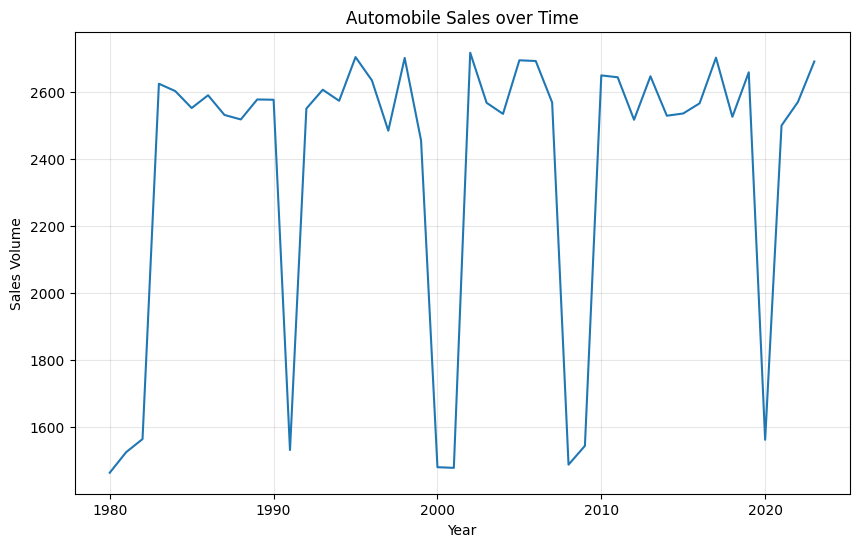

In [3]:
df_line = df.groupby('Year')['Automobile_Sales'].mean()
plt.figure(figsize=(10,6))
df_line.plot(kind='line')
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.title('Automobile Sales over Time')
plt.grid(alpha=0.3)
plt.show()

### TASK 1.2 — Sales trends by vehicle type during recession

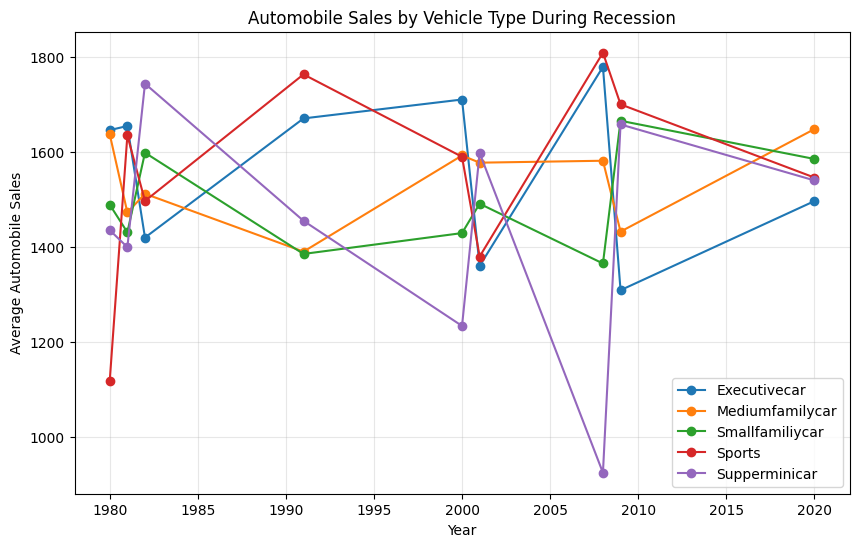

In [4]:
df_rec = df[df['Recession'] == 1]
df_Mline = df_rec.groupby(['Year','Vehicle_Type'], as_index=False)['Automobile_Sales'].mean()
plt.figure(figsize=(10,6))
for vehicle_type in df_Mline['Vehicle_Type'].unique():
    data = df_Mline[df_Mline['Vehicle_Type'] == vehicle_type]
    plt.plot(data['Year'], data['Automobile_Sales'], marker='o', label=vehicle_type)
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales by Vehicle Type During Recession')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### TASK 1.3 — Compare recession and non-recession sales

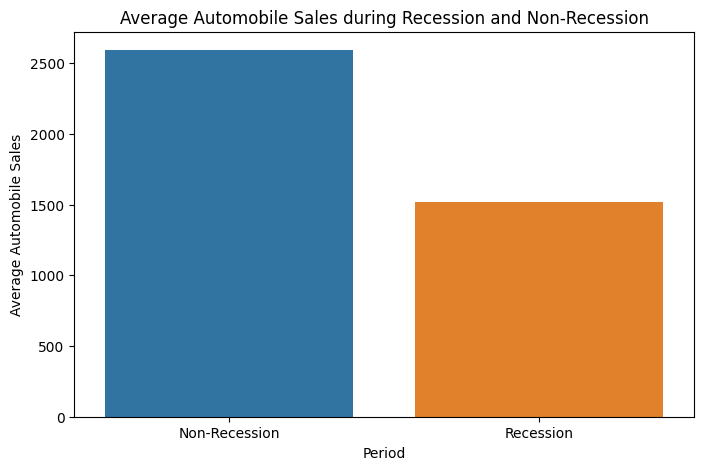

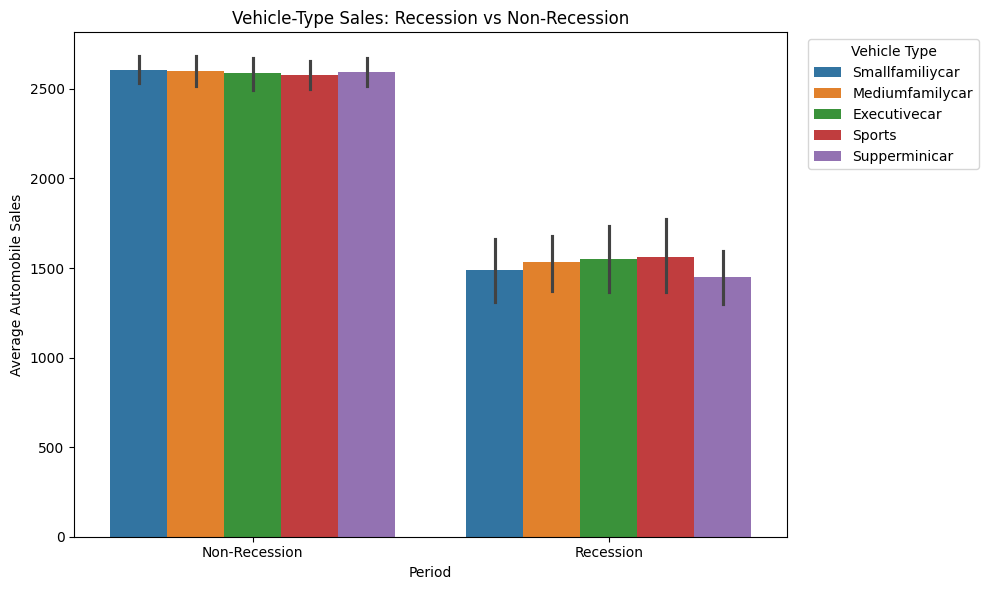

In [5]:
new_df = df.groupby('Recession', as_index=False)['Automobile_Sales'].mean()
plt.figure(figsize=(8,5))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession', data=new_df, legend=False)
plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0,1], labels=['Non-Recession','Recession'])
plt.show()

plt.figure(figsize=(10,6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=df)
plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Type Sales: Recession vs Non-Recession')
plt.xticks(ticks=[0,1], labels=['Non-Recession','Recession'])
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

### TASK 1.4 — GDP variation during recession and non-recession

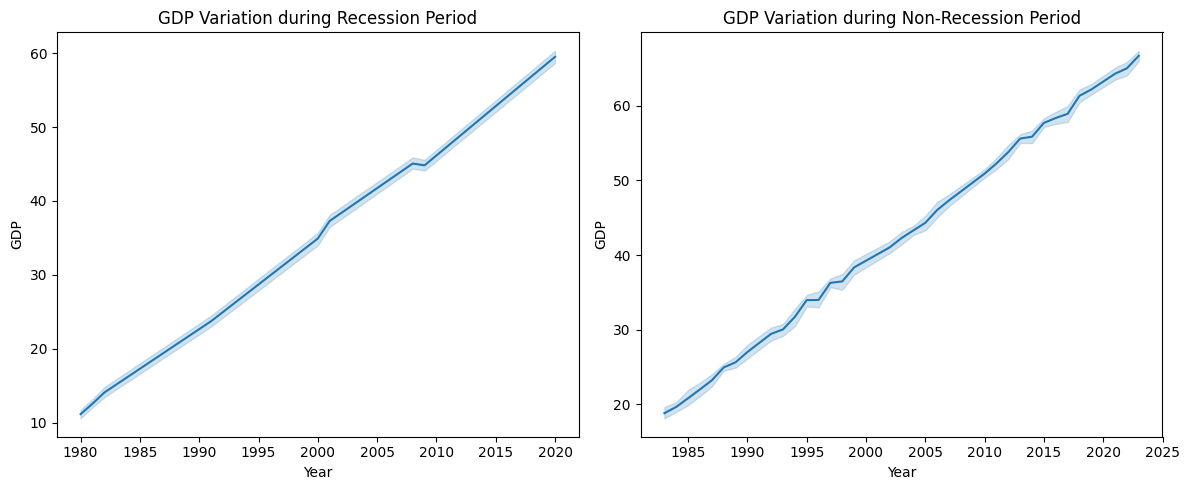

In [6]:
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

fig = plt.figure(figsize=(12,5))
ax0 = fig.add_subplot(1,2,1)
ax1 = fig.add_subplot(1,2,2)

sns.lineplot(x='Year', y='GDP', data=rec_data, ax=ax0)
ax0.set_title('GDP Variation during Recession Period')
ax0.set_xlabel('Year'); ax0.set_ylabel('GDP')

sns.lineplot(x='Year', y='GDP', data=non_rec_data, ax=ax1)
ax1.set_title('GDP Variation during Non-Recession Period')
ax1.set_xlabel('Year'); ax1.set_ylabel('GDP')

plt.tight_layout()
plt.show()

### TASK 1.5 — Seasonality impact on automobile sales

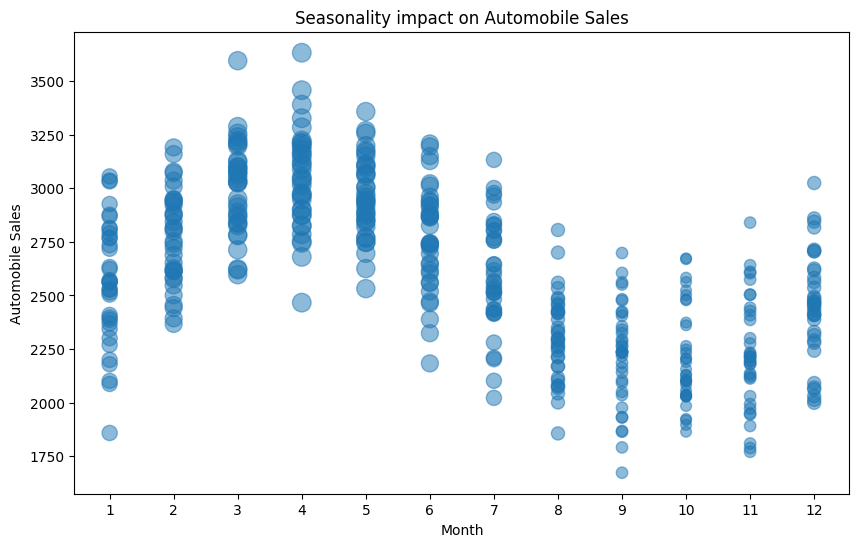

In [7]:
non_rec_data = df[df['Recession'] == 0]
size = non_rec_data['Seasonality_Weight'].clip(lower=0.05) * 120
plt.figure(figsize=(10,6))
plt.scatter(non_rec_data['Month'], non_rec_data['Automobile_Sales'],
            s=size, alpha=0.5)
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality impact on Automobile Sales')
plt.xticks(range(1,13))
plt.show()

### TASK 1.6 — Consumer confidence and automobile sales during recessions

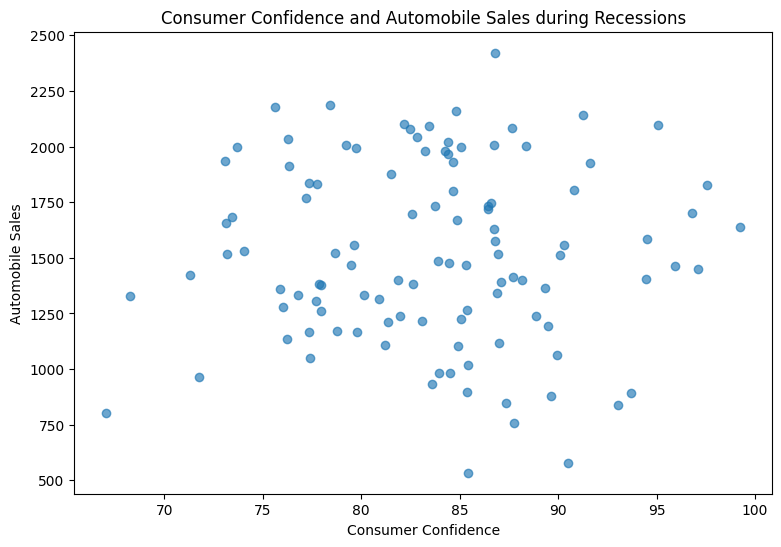

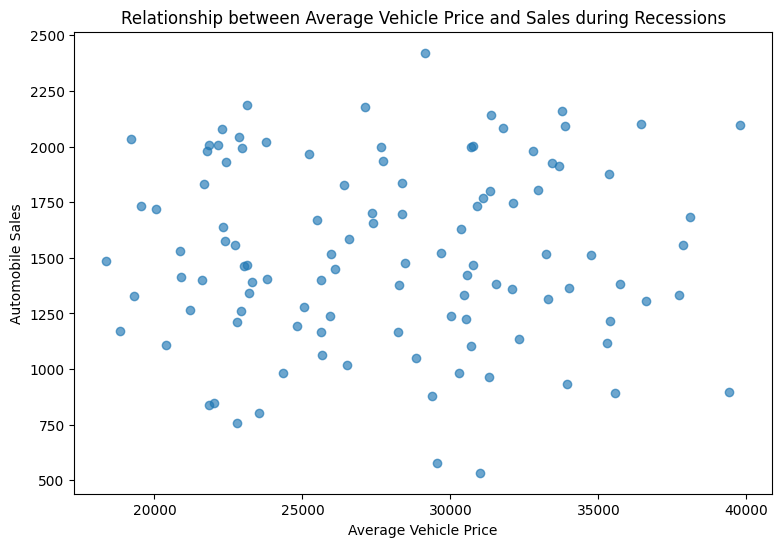

In [8]:
rec_data = df[df['Recession'] == 1]
plt.figure(figsize=(9,6))
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'], alpha=0.65)
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.show()

plt.figure(figsize=(9,6))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'], alpha=0.65)
plt.xlabel('Average Vehicle Price')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Average Vehicle Price and Sales during Recessions')
plt.show()

### TASK 1.7 — Advertising expenditure during recession and non-recession

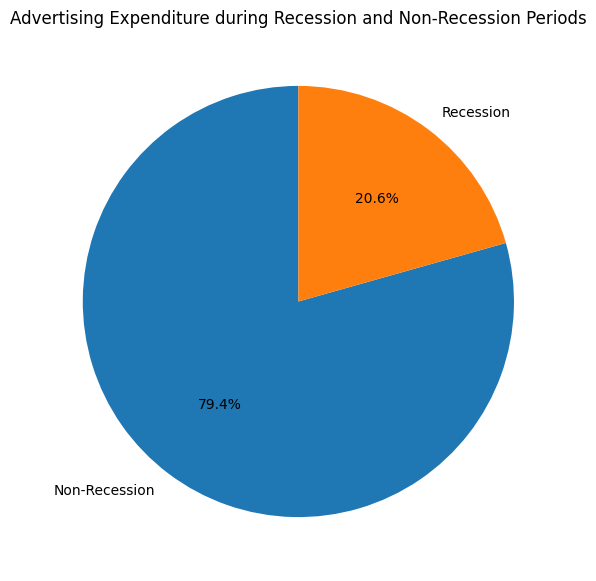

In [9]:
exp = df.groupby('Recession')['Advertising_Expenditure'].sum()
plt.figure(figsize=(7,7))
plt.pie(exp.values, labels=['Non-Recession','Recession'], autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure during Recession and Non-Recession Periods')
plt.show()

### TASK 1.8 — Advertisement expenditure by vehicle type during recession

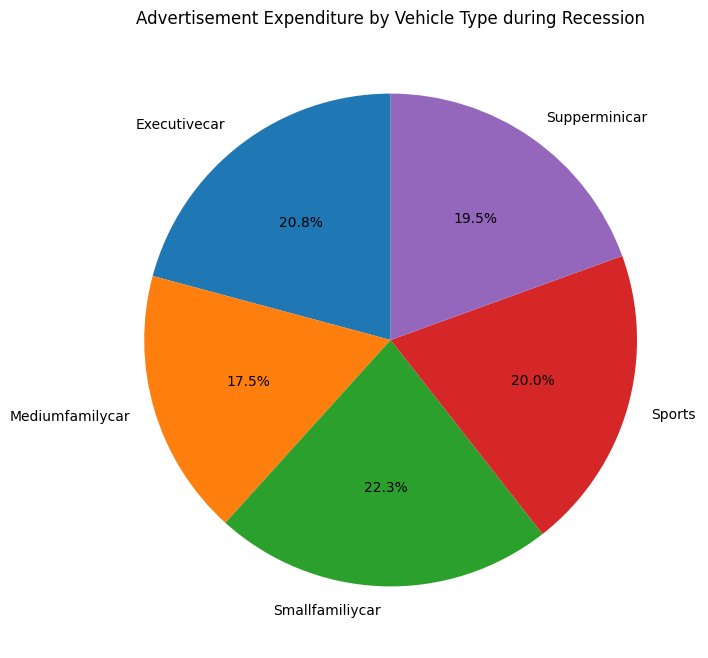

In [10]:
recession_data = df[df['Recession'] == 1]
veh_exp = recession_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
plt.figure(figsize=(8,8))
plt.pie(veh_exp.values, labels=veh_exp.index, autopct='%1.1f%%', startangle=90)
plt.title('Advertisement Expenditure by Vehicle Type during Recession')
plt.show()

### TASK 1.9 — Effect of unemployment rate on vehicle type and sales

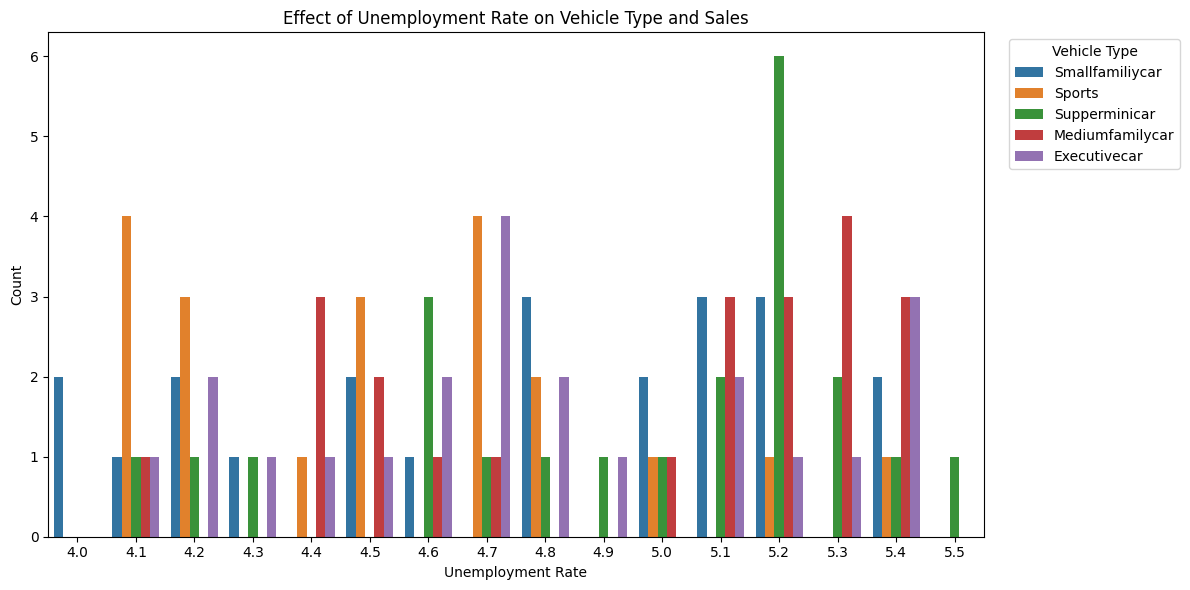

In [11]:
recession_data = df[df['Recession'] == 1]
plt.figure(figsize=(12,6))
sns.countplot(x='unemployment_rate', hue='Vehicle_Type', data=recession_data)
plt.xlabel('Unemployment Rate')
plt.ylabel('Count')
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

## Completed
All required Part 1 visualization exercises (Tasks **1.1–1.9**) are included above.
